Connecting to hydrodynamic model server...
Shear stress calculations complete! Generating figures...


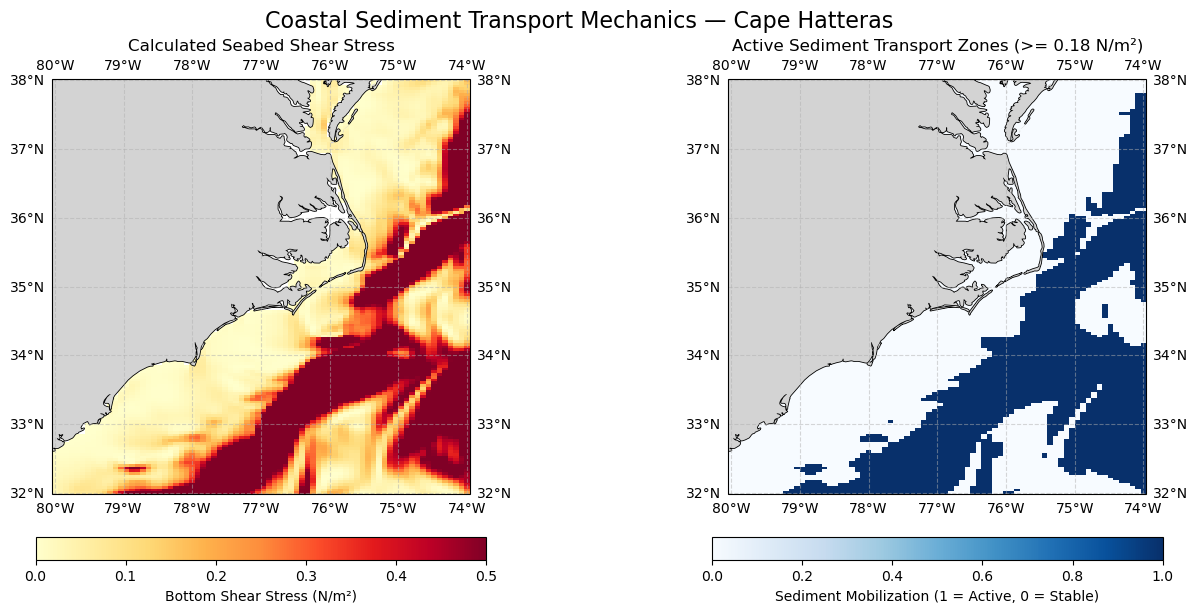

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Connecting to HYCOM ocean hydrodynamic model
url = "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0"
print("Connecting to hydrodynamic model server...")
ds = xr.open_dataset(url, decode_times=False)

# Slicing data off Cape Hatteras
model = ds.sel(
    depth=0,
    lat=slice(32, 38),
    lon=slice(280, 286)
).isel(time=0)

# Extracting velocity components and calculating total current speed U
u = model.water_u
v = model.water_v
speed = np.sqrt(u**2 + v**2)

# Defining Physical Constants & calculating botton shear stress
rho = 1025.0         # Seawater density (kg/m³)
Cd = 0.0025          # Seabed drag coefficient
tau_critical = 0.18  # Threshold for sand mobilization (N/m²)
tau_b = rho * Cd * (speed**2)

# Masking zones where sediment erosion/transport is actively occurring
active_erosion = xr.where(tau_b >= tau_critical, 1, 0)

print("Shear stress calculations complete")

# Plot 2-panel comparison map
fig, (ax1, ax2) = plt.subplots(
    1, 2, 
    figsize=(16, 7), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Formating map geography
for ax in [ax1, ax2]:
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# Panel 1: Bottom Shear Stress Grid
pcm1 = ax1.pcolormesh(
    tau_b.lon, tau_b.lat, tau_b,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd', vmin=0, vmax=0.5, zorder=1
)
cbar1 = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cbar1.set_label('Bottom Shear Stress (N/m²)')
ax1.set_title('Calculated Seabed Shear Stress')

# Panel 2: Active Sediment Transport Zone
pcm2 = ax2.pcolormesh(
    active_erosion.lon, active_erosion.lat, active_erosion,
    transform=ccrs.PlateCarree(),
    cmap='Blues', vmin=0, vmax=1, zorder=1
)
cbar2 = fig.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cbar2.set_label('Sediment Mobilization (1 = Active, 0 = Stable)')
ax2.set_title('Active Sediment Transport Zones (>= 0.18 N/m²)')

plt.suptitle('Coastal Sediment Transport Mechanics — Cape Hatteras', fontsize=16)

# 7. Save output figure
plt.savefig("../figures/sediment_transport_model.png", dpi=300, bbox_inches='tight')
plt.show()